<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W2-Manasa/W2D1_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import SelectKBest, f_regression

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
data = df[
    ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
].dropna()

print("Cleaned dataset shape:", data.shape)
display(data.head())

Cleaned dataset shape: (712, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
label_encoder = LabelEncoder()

data["Sex_Label"] = label_encoder.fit_transform(data["Sex"])

print(data[["Sex", "Sex_Label"]].head(10))
print("\nMapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

       Sex  Sex_Label
0     male          1
1   female          0
2   female          0
3   female          0
4     male          1
6     male          1
7     male          1
8   female          0
9   female          0
10  female          0

Mapping:
{'female': np.int64(0), 'male': np.int64(1)}


In [ ]:
one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_embarked = one_hot_encoder.fit_transform(
    data[["Embarked"]]
)

encoded_embarked_df = pd.DataFrame(
    encoded_embarked,
    columns=one_hot_encoder.get_feature_names_out(["Embarked"]),
    index=data.index
)

display(encoded_embarked_df.head())

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [ ]:
ordinal_encoder = OrdinalEncoder()

data["Pclass_Ordinal"] = ordinal_encoder.fit_transform(
    data[["Pclass"]]
)

display(data[["Pclass", "Pclass_Ordinal"]].head(10))

,Pclass,Pclass_Ordinal
0,3,2.0
1,1,0.0
2,3,2.0
3,1,0.0
4,3,2.0
6,1,0.0
7,3,2.0
8,3,2.0
9,2,1.0
10,3,2.0


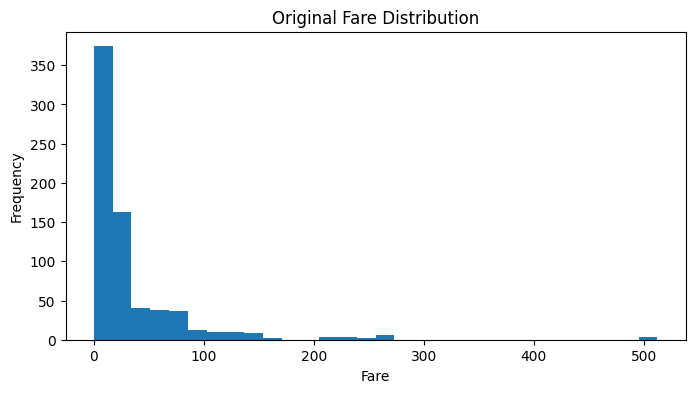

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(data["Fare"], bins=30)
plt.title("Original Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [ ]:
standard_scaler = StandardScaler()

data["Fare_Standard"] = standard_scaler.fit_transform(
    data[["Fare"]]
)

In [ ]:
minmax_scaler = MinMaxScaler()

data["Fare_MinMax"] = minmax_scaler.fit_transform(
    data[["Fare"]]
)

In [ ]:
robust_scaler = RobustScaler()

data["Fare_Robust"] = robust_scaler.fit_transform(
    data[["Fare"]]
)

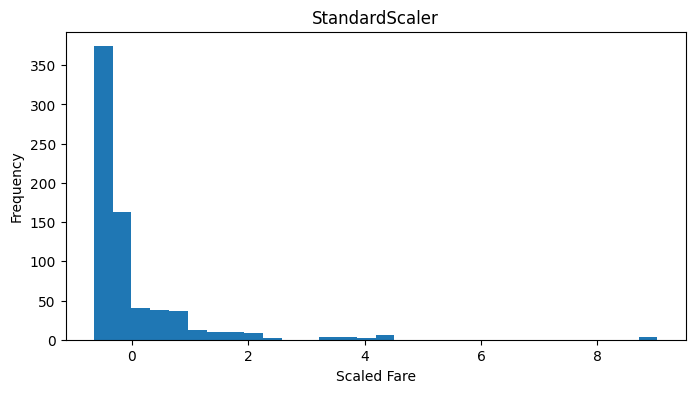

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(data["Fare_Standard"], bins=30)
plt.title("StandardScaler")
plt.xlabel("Scaled Fare")
plt.ylabel("Frequency")
plt.show()

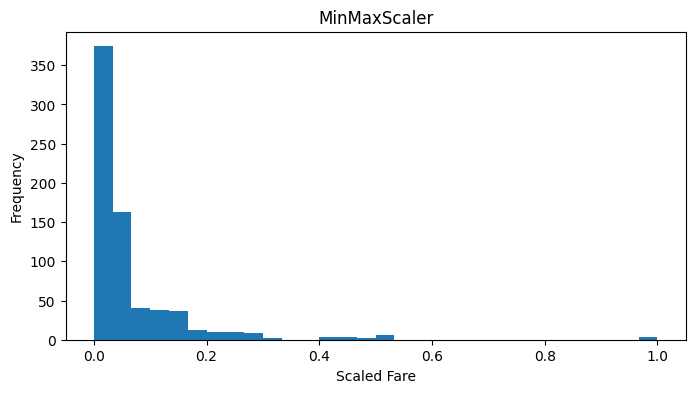

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(data["Fare_MinMax"], bins=30)
plt.title("MinMaxScaler")
plt.xlabel("Scaled Fare")
plt.ylabel("Frequency")
plt.show()

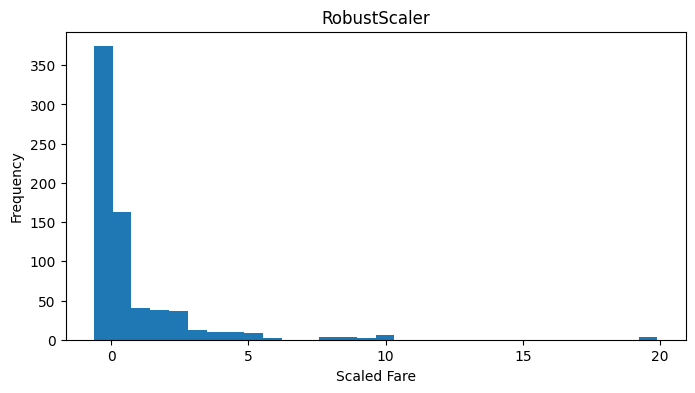

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(data["Fare_Robust"], bins=30)
plt.title("RobustScaler")
plt.xlabel("Scaled Fare")
plt.ylabel("Frequency")
plt.show()

In [ ]:
features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X = data[features]
y = data["Survived"]

In [ ]:
selector = SelectKBest(
    score_func=f_regression,
    k=5
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 features:")
for feature in selected_features:
    print(feature)

Top 5 features:
Pclass
Age
SibSp
Parch
Fare


In [ ]:
feature_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex_Label",
    "Pclass_Ordinal"
]

X = data[feature_columns]
y = data["Survived"]

selector = SelectKBest(
    score_func=f_regression,
    k=5
)

X_selected = selector.fit_transform(X, y)

scores = pd.Series(
    selector.scores_,
    index=X.columns
).sort_values(ascending=False)

print("Feature scores:")
display(scores)

print("Top 5 features:")
print(scores.head(5))

Feature scores:


,0
Sex_Label,287.349355
Pclass_Ordinal,103.347946
Pclass,103.347946
Fare,54.105548
Parch,6.502602
Age,4.859127
SibSp,0.171126


Top 5 features:
Sex_Label         287.349355
Pclass_Ordinal    103.347946
Pclass            103.347946
Fare               54.105548
Parch               6.502602
dtype: float64


## Feature Selection — Top 5 Features

SelectKBest was used to identify the five features with the highest statistical relationship with the target variable `Survived`.

### Why the selected features matter

- **Pclass:** Passenger class is related to socioeconomic status and survival probability.
- **Sex_Label:** Encoded passenger sex can capture differences in survival patterns.
- **Fare:** Fare can provide information about passenger class and socioeconomic status.
- **Age:** Age can influence survival, especially for children and older passengers.
- **Parch/SibSp:** Family relationships may influence survival and evacuation behavior.

Feature importance here is based on the statistical scores produced by SelectKBest, not on causal relationships.

## Self-Review Checklist

- [x] LabelEncoder applied
- [x] OneHotEncoder applied
- [x] OrdinalEncoder applied
- [x] StandardScaler applied
- [x] MinMaxScaler applied
- [x] RobustScaler applied
- [x] Scaling distributions plotted
- [x] SelectKBest used to identify top 5 features
- [x] Feature importance documented
- [x] Output evidence captured